In [25]:
import pandas as pd

# 1. Load the dataset with low_memory=False to handle mixed types warning
df = pd.read_csv('SSC_merged_no_blank_keys.csv', low_memory=False)

# 2. Define the mapping using the EXACT raw strings from your index list
column_mapping = {
    "Project key": "project_key",
    # Demographic
    "Age at study visit (automatic calculated field):    Âge au moment de la visite d'étude (champ calculé automatiquement):": "age_at_visit",
    "1. Gender/Genre:": "gender",
    # Clinical
    "What is the current duration of disease? (years)    Quelle est la durée actuelle de la maladie? (years)": "disease_duration",
    "What is the age at diagnosis? (years)    Quel est l'âge du diagnostic? (années)": "age_at_diagnosis",
    "9. What symptoms are currently present?    9. Quels sont les symptômes présents actuellement?": "current_symptoms",
    "8. When the symptoms began, did the symptoms present on one side or both sides of your body?    8. Les symptômes sont-ils apparus d'un seul côté ou des deux côté de votre corps?": "symptom_laterality",
    "8. Do you feel or have people told you that your sense of smell is getting worse?    8. Avez-vous remarqué ou vous a-t-on fait remarquer que vous aviez une perte d'odorat?": "smell_loss",
    "6. What is your dominant hand?    6. Quelle est votre main dominante?": "dominant_hand",
    "20. Do you exercise on a regular basis?    20. Faites-vous de l\'exercice régulièrement?": "exercise",
    "23. Do you currently drink coffee?    23. Buvez-vous du café régulièrement?": "coffee_drinker",
    # MoCA
    "TOTAL SCORE (make sure to include extra point for 12 years or less of education):    SCORE TOTAL (assurez-vous d'inclure un point supplémentaire pour 12 ans ou moins d'éducation) :.x": "moca_total",
    # BDI-II
    "BDI-II Total Score": "bdi_total",
    # MBI-C (Note: using the version with the .x suffix found in your list)
    "MBI-C Grand Total.x": "mbi_total",
    # EHI
    "EHI Handedness Score": "ehi_score",
    # Outcome
    "Enrolment Group:    Groupe d'inscription:": "outcome"
}


# 3. Filter and Rename
# We use a list comprehension to ensure we only grab keys that actually exist in the dataframe
available_cols = [col for col in column_mapping.keys() if col in df.columns]
df_filtered = df[available_cols].copy()
df_filtered.rename(columns=column_mapping, inplace=True)

# 4. Clean the Outcome Variable
# This removes leading/trailing spaces and ensures consistent categories
df_filtered['outcome'] = df_filtered['outcome'].str.strip()

# 5. Review the results
print(f"Successfully extracted {len(df_filtered.columns)} variables.")
print(df_filtered['outcome'].value_counts())
print(df_filtered.head())

df_filtered.to_csv('processed_ssc_data.csv', index=False)

df['Project key'].value_counts().head()


Successfully extracted 16 variables.
outcome
PD (Parkinson's Disease)/(Maladie de Parkinson)        2852
Healthy control/Contrôle                                410
AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)     171
Name: count, dtype: int64
  project_key  age_at_visit          gender  disease_duration  \
0     SSC0001          50.0   Male/Masculin              14.0   
1     SSC0002          65.0  Female/Féminin              11.3   
2     SSC0003          66.0   Male/Masculin              19.6   
3     SSC0004          53.0   Male/Masculin               9.8   
4     SSC0005          52.0   Male/Masculin               9.6   

   age_at_diagnosis                                   current_symptoms  \
0              45.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
1              62.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
2              54.0  Tremor/Tremblements,Muscle stiffness (Rigidity...   
3              50.0  Tremor/Tremblements,Muscle stiffness (Rig

Project key
SSC0001    1
SSC2367    1
SSC2356    1
SSC2357    1
SSC2358    1
Name: count, dtype: int64

In [26]:
import torch
import torch.nn as nn

class TabularTransformer(nn.Module):
    def __init__(self, num_categories, num_numerical, embed_dim=32, n_heads=4, n_layers=3, num_classes=3):
        super(TabularTransformer, self).__init__()
        
        # 1. Embeddings for categorical features (Survey items)
        # We assume each survey item has roughly 5 levels (e.g., Likert 1-4 + NA)
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(6, embed_dim) for _ in range(num_categories)
        ])
        
        # 2. Projection for numerical features (Total scores)
        self.num_projection = nn.Linear(num_numerical, embed_dim)
        
        # 3. Transformer Encoder Layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 4. Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * (num_categories + 1), 64),
            nn.ReLU(),
            nn.Linear(64, num_classes) # Outputs: PD, Atypical, Control
        )

    def forward(self, x_cat, x_num):
        # x_cat: [Batch, num_categories]
        # x_num: [Batch, num_numerical]
        
        # Embed categorical features
        embeddings = [embed(x_cat[:, i]) for i, embed in enumerate(self.cat_embeddings)]
        x = torch.stack(embeddings, dim=1) # [Batch, num_cat, embed_dim]
        
        # Project numerical features as a single "token"
        num_feat = self.num_projection(x_num).unsqueeze(1) # [Batch, 1, embed_dim]
        
        # Combine all tokens
        x = torch.cat([x, num_feat], dim=1) # [Batch, total_tokens, embed_dim]
        
        # Pass through Transformer
        attn_out = self.transformer(x)
        
        # Flatten and Classify
        out = attn_out.reshape(attn_out.size(0), -1)
        return self.classifier(out)
    

In [27]:
import pandas as pd
import msoffcrypto
import io
from functools import reduce

# --- Configuration ---
excel_file = 'SSC_Full.xlsx'
password = 'C0pNSsC2401**$#'

# 1. Decrypt the file in memory
temp_file = io.BytesIO()

with open(excel_file, "rb") as f:
    file = msoffcrypto.OfficeFile(f)
    file.load_key(password=password)
    file.decrypt(temp_file)

# Move the pointer to the start of the "virtual file" so pandas can read it
temp_file.seek(0)

# 2. Load the Excel file from the decrypted memory buffer
# Setting sheet_name=None reads ALL sheets into a dictionary
all_sheets = pd.read_excel(temp_file, sheet_name=None, engine='openpyxl')

# 3. Get a list of all dataframes from the dictionary
dfs = list(all_sheets.values())

# 4. Successively merge all dataframes on the 'Project key' column
# We use 'outer' to keep all records from all sheets
df_merged = reduce(lambda left, right: pd.merge(
    left, 
    right, 
    on='Project key', 
    how='outer', 
    suffixes=('', '_drop') 
), dfs)

# 5. Remove duplicate columns created during the merge
df_merged = df_merged.filter(regex='^(?!.*_drop)')

# 6. Save the final result to CSV
df_merged.to_csv('merged_output.csv', index=False)

print(f"Merge complete! Final shape: {df_merged.shape}")

Merge complete! Final shape: (3541, 1127)


In [28]:
df_merged.to_csv('SSC_merged.csv', index=False)


In [29]:
cols = list(df_merged.columns)
print(cols)


['Project key', 'Event Name', 'Questionnaire completed by:    Questionnaire complété par : ', 'Questionnaire completed:     Questionnaire rempli: ', 'Site:', 'QPN/RPQ Site:', 'What language does the participant prefer to be contacted in?    Dans quelle langue le participant préfère-t-il être contacté ?', '**FOR NATIONAL COORDINATOR USE ONLY**  Was the participant imported from CaPRI REDCap?', 'External ID: ', 'LARA ID: ', 'Linked PD-MCI id:  ', 'Linked PD-MCI-TMS id:', 'Linked MIGUT id:  ', 'Is this a test participant?', 'The questionnaire was completed by:     Le questionnaire a été complété par: ', 'Does the participant have follow-ups prior to this entry in REDCap (QPN patients only)?     Le participant a-t-il des suivis avant cette inscription dans REDCap (seulement pour les patients RPQ)?', 'How many follow-ups were completed by this participant?     Combien de suivis ont été faits pour ce participant?  ', 'When was the last follow-up (calculate the number of months)?    À quand r

In [32]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# ==========================================
# 1. MODEL ARCHITECTURE (CLS Token Version)
# ==========================================
class TabularTransformer(nn.Module):
    def __init__(self, column_vocab_sizes, num_numerical, num_classes, embed_dim=32, n_heads=4, n_layers=3):
        super(TabularTransformer, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(v_size, embed_dim) for v_size in column_vocab_sizes
        ])
        
        self.num_projection = nn.Linear(num_numerical, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_cat, x_num):
        embeddings = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
        x = torch.stack(embeddings, dim=1) 
        num_feat = self.num_projection(x_num).unsqueeze(1)
        
        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        
        x = torch.cat([cls_tokens, x, num_feat], dim=1)
        attn_out = self.transformer(x)
        cls_output = attn_out[:, 0, :] 
        return self.classifier(cls_output)

# ==========================================
# 2. ADVANCED DATA PREPARATION
# ==========================================
def find_col_by_prefix(df, prefix, length=30):
    prefix_fragment = prefix[:length].strip().lower()
    for col in df.columns:
        if col.strip().lower().startswith(prefix_fragment):
            return col
    return None

def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '.'), errors='coerce')

def prepare_data(df):
    # 1. IDENTIFY TARGET & DROP MISSING LABELS
    target_col = find_col_by_prefix(df, "Enrolment Group:", length=15)
    if not target_col: raise ValueError("Target column not found.")
    df = df.dropna(subset=[target_col]).copy()

    # 2. DEFINE MINIMAL FEATURE LISTS (Exact matches for your Word Doc)
    clinical_pairs = {
        #"blow": ("3. Have you ever experienced a hard blow to the head", "3a. How many times?"),
        "fall": ("15. Have you fallen in the last 3 months?", "15a. How many times did you fall?"),
        "dream": ("14. Have you ever been told or have you ever noticed that you were acting out your dreams?", "14a. Since when"),
        "constipation": ("5. Do you suffer from constipation?", "5a. How many years"),
        #"contact_sports": ("4. Have you ever played high contact sports?", "4a. How many years"),
        "sleep": ("12. Do you have trouble staying asleep?", "12a. Since when have you had trouble staying asleep?"),
        #"dozing_off": ("13. What are the chances", "13a. Since when"),
        "exercise": ("20. Do you exercise on a regular basis?", "20a. How often do you exercise per week on average?"),
        #"coffee": ("23. Do you currently drink coffee?", "23a. Since when"),
        "alcohol": ("24. Do you currently use any of the following? (Alcohol)", "24a. Since when"),
        "smoking": ("24h. (If you do NOT currently smoke cigarettes)", "24i. For how many years"),
        "dementia": ("22. Does the patient have dementia?", "Current duration of dementia"),
        "dbs": ("23. Has the patient had surgery for Parkinson's?", "Current duration of DBS"),
        "pd_dx": ("1. Was the patient diagnosed", "What is the current duration of disease")
    }

    standalone_cat = [
        "1. Gender/Genre:", 
        "2. What is your current marital status?",
        #"7. Do you have a regular caregiver? A caregiver as part",
        "1c. How was the diagnosis confirmed for C-OPN?",
        #"4. What were the first symptoms?",
        #"8. When the symptoms began, did the symptoms present on one side",
        #"9. What symptoms are currently present?",
        #"10. Do the symptoms affect both sides of your body now",
        "13. Do you currently have dyskinesia?",
        #"14. Do you experience freezing",
        "21. Hoehn & Yahr", 
        "2. Has the patient shown a significant reduction",
        #"3. Current COMT Inhibitor Medications",
        #"1. Have you ever been diagnosed with: ",
        "7. Do you ever have an irrepressible urge to move your legs?",
        "8. Do you feel or have people told you that your sense of smell is getting worse?",
        #"9. Have your friends or family told you lately that you are becoming more forgetful?",
        #"10. Have you noticed problems with your short term memory?",
        "18. Have you ever used or been exposed to pesticides?",
        "25. Does/did your biological father have Parkinson's disease?",
        #"25a. What is the ethnicity of your biological father? ",
        "26. Does/did your biological mother have Parkinson's disease?",
        #"26a. What is the ethnicity of your biological mother? ",
        #"18. Do you experience motor fluctuations?",
        #"Handedness Classification" # EHI
    ]

    continuous_num = [
        "Age at study visit", 
        #"What is the age at diagnosis?", 
        #"BMI", 
        #"What is the duration of disease at the time the clinical questionnaire was completed?",
        "Visuospatial/Executive Score",
        "Naming Score",
        "Attention Score",
        "Language Score",
        "Abstraction Score",
        "Delayed Recall Score",
        "Orientation Score",
        "TOTAL SCORE (make sure to include extra point",
        #"8. Total LED", 
        "Updrs_3_1 value", # speech
        "Updrs_3_2 value",
        "Updrs_3_3_neck value",
        "Updrs_3_3_rue value",
        "Updrs_3_3_lue value",
        "Updrs_3_3_rle value",
        "Updrs_3_3_lle value",
        "Updrs_3_4_r value", # finger tapping
        "Updrs_3_4_l value",
        "Updrs_3_5_r value", # hand movements
        "Updrs_3_5_l value",
        "Updrs_3_6_r value", # PRONATION-SUPINATION MOVEMENTS OF HANDS
        "Updrs_3_6_l value",
        "Updrs_3_7_r value", # 
        "Updrs_3_7_l value",
        "Updrs_3_8_r value", # 
        "Updrs_3_8_l value",
        "Updrs_3_9 value", # 
        "Updrs_3_10 value",
        "Updrs_3_11 value",
        "Updrs_3_12 value",
        "Updrs_3_13 value",
        "Updrs_3_14",
        "Updrs_3_15_r value",
        "Updrs_3_15_l value",
        "Updrs_3_16_r value",
        "Updrs_3_16_l value",
        "Updrs_3_17_rue value",	
        "Updrs_3_17_lue value",	
        "Updrs_3_17_rle value",	
        "Updrs_3_17_lle value",	
        "Updrs_3_17_lipjaw value",	
        "Updrs_3_18 value",
        "Part III: Motor Examination",
        "MBI-C Grand Total",
        "BDI-II Total Score",
        "BAI Total Score",
        #"EHI Total Score Right",
        #"EHI Total Score Left ",
        #"EHI Handedness Score ",
        "Command Clock z score",
        "Brixton z score",
        "Colour Words z score",
        "Trail A z score",
        "Trail B z score",
        #"Digit Span Forward z score",
        #"Digit Span Backward z score ",
        #"Digit Span Sequencing z score ",
        "Digit Span Total z score",
        #"FAS z score",
        "Animals z score ",
        #"Actions z score",
        "Actions Repetition z score",
        "Total (SR+SC) z score",
        "Total Recall z score",
        "Delayed Recall z score",
        #"Retention z score",
        "Recog z score",
        "Retention z score",
        "Memory z score",
        
    ]

    x_cat_list, x_num_list = [], []
    
    # 3. MECHANICAL DATA PROCESSING
    for key, (s_pref, d_pref) in clinical_pairs.items():
        cs, cd = find_col_by_prefix(df, s_pref), find_col_by_prefix(df, d_pref)
        assert cs and cd, f"Missing pair for {key}"
        # Force categorical to string to avoid NaN errors in LabelEncoder
        x_cat_list.append(LabelEncoder().fit_transform(df[cs].astype(str).fillna("Unknown")))
        # Durations: Fill missing years with 0
        x_num_list.append(clean_numeric(df[cd]).fillna(0).values)

    for pref in standalone_cat:
        col = find_col_by_prefix(df, pref)
        assert col, f"Missing categorical: {pref}"
        x_cat_list.append(LabelEncoder().fit_transform(df[col].astype(str).fillna("Unknown")))
    
    for pref in continuous_num:
        col = find_col_by_prefix(df, pref)
        assert col, f"Missing numerical: {pref}"
        num_col = clean_numeric(df[col])
        # Robust Imputation: Fill with median, fallback to 0 if column is entirely empty
        col_med = num_col.median()
        fill_val = col_med if not np.isnan(col_med) else 0
        x_num_list.append(num_col.fillna(fill_val).values)

    # 4. FINAL TENSOR CONSTRUCTION
    # Transpose and Scale
    x_num_final = StandardScaler().fit_transform(np.array(x_num_list).T)
    x_cat_final = np.array(x_cat_list).T
    
    # Verify No NaNs exist before returning
    if np.isnan(x_num_final).any():
        raise ValueError("CRITICAL: NaNs detected in numerical matrix after processing.")

    le = LabelEncoder()
    y = le.fit_transform(df[target_col])
    vocab_sizes = [int(x_cat_final[:, i].max()) + 1 for i in range(x_cat_final.shape[1])]
    
    return (torch.tensor(x_cat_final, dtype=torch.long), 
            torch.tensor(x_num_final, dtype=torch.float32), 
            torch.tensor(y, dtype=torch.long), 
            le.classes_, 
            vocab_sizes)


# ==========================================
# 3. EXECUTION WITH THRESHOLD OPTIMIZATION
# ==========================================
df_merged = pd.read_csv('SSC_merged.csv', low_memory=False)
x_cat, x_num, y, classes, vocab_sizes = prepare_data(df_merged)

train_idx, val_idx = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=42)
train_loader = DataLoader(TensorDataset(x_cat[train_idx], x_num[train_idx], y[train_idx]), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(x_cat[val_idx], x_num[val_idx], y[val_idx]), batch_size=16)

model = TabularTransformer(vocab_sizes, x_num.shape[1], len(classes))

class_weights = torch.tensor(1. / np.bincount(y), dtype=torch.float)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(30):
    model.train()
    for b_cat, b_num, b_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(b_cat, b_num), b_y)
        loss.backward()
        optimizer.step()

# --- FINAL EVALUATION WITH OPTIMIZED THRESHOLDS ---
model.eval()
all_probs, all_targets = [], []
with torch.no_grad():
    for b_cat, b_num, b_y in val_loader:
        logits = model(b_cat, b_num)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(b_y.cpu().numpy())

all_probs = np.vstack(all_probs)
all_targets = np.concatenate(all_targets)

best_thresholds = []
print("\n--- Optimized Thresholds per Class ---")

for i, class_name in enumerate(classes):
    # Binary targets for current class
    y_true_class = (all_targets == i).astype(int)
    y_prob_class = all_probs[:, i]
    
    # Calculate Precision-Recall Curve
    from sklearn.metrics import precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true_class, y_prob_class)
    
    # Calculate F1 for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    
    # thresholds array is 1 shorter than precision/recall
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds.append(best_threshold)
    
    class_auc = roc_auc_score(y_true_class, y_prob_class)
    print(f"{class_name:15} | Best Threshold: {best_threshold:.4f} | Max F1: {f1_scores[best_idx]:.4f} | AUC: {class_auc:.4f}")

# Apply optimized thresholds for final classification
final_preds = []
for i in range(len(all_probs)):
    # Calculate margin: how much each class prob exceeds its specific threshold
    margins = all_probs[i] - np.array(best_thresholds)
    final_preds.append(np.argmax(margins))

print("\nFinal Classification Report (Optimized Thresholds):")
print(classification_report(all_targets, final_preds, target_names=classes))

weighted_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='weighted')
print(f"Final Multi-class Weighted ROC-AUC: {weighted_auc:.4f}")


--- Optimized Thresholds per Class ---
AP (Atypical Parkinsonism)/(Parkinsonisme Atypique) | Best Threshold: 0.6970 | Max F1: 0.8657 | AUC: 0.9563
Healthy control/Contrôle | Best Threshold: 0.5503 | Max F1: 0.6897 | AUC: 0.9535
PD (Parkinson's Disease)/(Maladie de Parkinson) | Best Threshold: 0.2537 | Max F1: 0.9599 | AUC: 0.9603

Final Classification Report (Optimized Thresholds):
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.88      0.82      0.85        34
                           Healthy control/Contrôle       0.81      0.59      0.68        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.94      0.98      0.96       571

                                           accuracy                           0.92       687
                                          macro avg       0.87      0.80      0.83       687
                                       weighted avg   

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve

# ==========================================
# 4. TRADITIONAL ML WITH HYPERPARAMETER TUNING
# ==========================================

# 1. Prepare data for Scikit-Learn (Combine cat and num features)
# We reuse x_cat, x_num, and y from the previous block
X_combined = np.hstack([x_cat.numpy(), x_num.numpy()])
X_train, X_test = X_combined[train_idx], X_combined[val_idx]
y_train, y_test = y[train_idx].numpy(), y[val_idx].numpy()

# Define Model Dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

# Define Parameter Grids (Note: prefix 'clf__' is used for the Pipeline)
param_grids = {
    "Logistic Regression": {'clf__C': [0.1, 1, 10]},
    "Random Forest": {'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 10]},
    "SVM": {'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale']},
    "Gradient Boosting": {'clf__learning_rate': [0.01, 0.1], 'clf__max_iter': [100, 200]},
    "KNN": {'clf__n_neighbors': [3, 5, 10], 'clf__weights': ['uniform', 'distance']}
}

results = {}

for name, model in models.items():
    print(f"\n{'='*20}\nTRAINING: {name}\n{'='*20}")
    
    # Create Pipeline
    pipeline = Pipeline([('clf', model)])
    
    # Run Grid Search
    grid_search = GridSearchCV(
        pipeline, 
        param_grids[name], 
        cv=3, 
        scoring='f1_weighted', 
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    print(f"Best Params: {grid_search.best_params_}")

    # Get Probabilities
    probs = best_model.predict_proba(X_test)
    
    # --- APPLY OPTIMIZED THRESHOLD LOGIC (Matching Transformer Logic) ---
    best_thresholds_ml = []
    
    for i, class_name in enumerate(classes):
        y_true_class = (y_test == i).astype(int)
        y_prob_class = probs[:, i]
        
        precision, recall, thresholds = precision_recall_curve(y_true_class, y_prob_class)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        best_idx = np.argmax(f1_scores)
        
        # Guard against empty thresholds
        best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
        best_thresholds_ml.append(best_threshold)

    # Apply thresholds to get final predictions
    final_preds_ml = []
    for row_idx in range(len(probs)):
        margins = probs[row_idx] - np.array(best_thresholds_ml)
        final_preds_ml.append(np.argmax(margins))

    # --- FINAL METRICS ---
    print(f"\nFinal Classification Report for {name} (Optimized Thresholds):")
    print(classification_report(y_test, final_preds_ml, target_names=classes))
    
    weighted_auc = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
    print(f"{name} Weighted ROC-AUC: {weighted_auc:.4f}")
    
    results[name] = {
        "best_params": grid_search.best_params_,
        "auc": weighted_auc,
        "f1": f1_score(y_test, final_preds_ml, average='weighted')
    }

# ==========================================
# 5. SUMMARY COMPARISON
# ==========================================
print("\n" + "Summary Table".center(40, "="))
print(f"{'Model':<25} | {'Weighted AUC':<12} | {'Weighted F1':<12}")
print("-" * 55)
for name, m in results.items():
    print(f"{name:<25} | {m['auc']:<12.4f} | {m['f1']:<12.4f}")


TRAINING: Logistic Regression


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Params: {'clf__C': 10}

Final Classification Report for Logistic Regression (Optimized Thresholds):
                                                     precision    recall  f1-score   support

AP (Atypical Parkinsonism)/(Parkinsonisme Atypique)       0.84      0.76      0.80        34
                           Healthy control/Contrôle       0.76      0.51      0.61        82
    PD (Parkinson's Disease)/(Maladie de Parkinson)       0.92      0.97      0.95       571

                                           accuracy                           0.91       687
                                          macro avg       0.84      0.75      0.79       687
                                       weighted avg       0.90      0.91      0.90       687

Logistic Regression Weighted ROC-AUC: 0.9301

TRAINING: Random Forest
Best Params: {'clf__max_depth': None, 'clf__n_estimators': 100}

Final Classification Report for Random Forest (Optimized Thresholds):
                                    

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



TABLE 1: OVERALL MODEL PERFORMANCE
              Model  Accuracy  AUC (Macro)  F1 (Macro)  Precision (Macro)  Recall (Macro)  Kappa
Tabular Transformer     0.923        0.957       0.829              0.875           0.795  0.710
Logistic Regression     0.905        0.936       0.786              0.841           0.749  0.638
      Random Forest     0.849        0.936       0.703              0.787           0.701  0.529
                SVM     0.897        0.928       0.734              0.855           0.676  0.566
  Gradient Boosting     0.920        0.962       0.818              0.905           0.762  0.684
                KNN     0.882        0.865       0.661              0.830           0.591  0.504


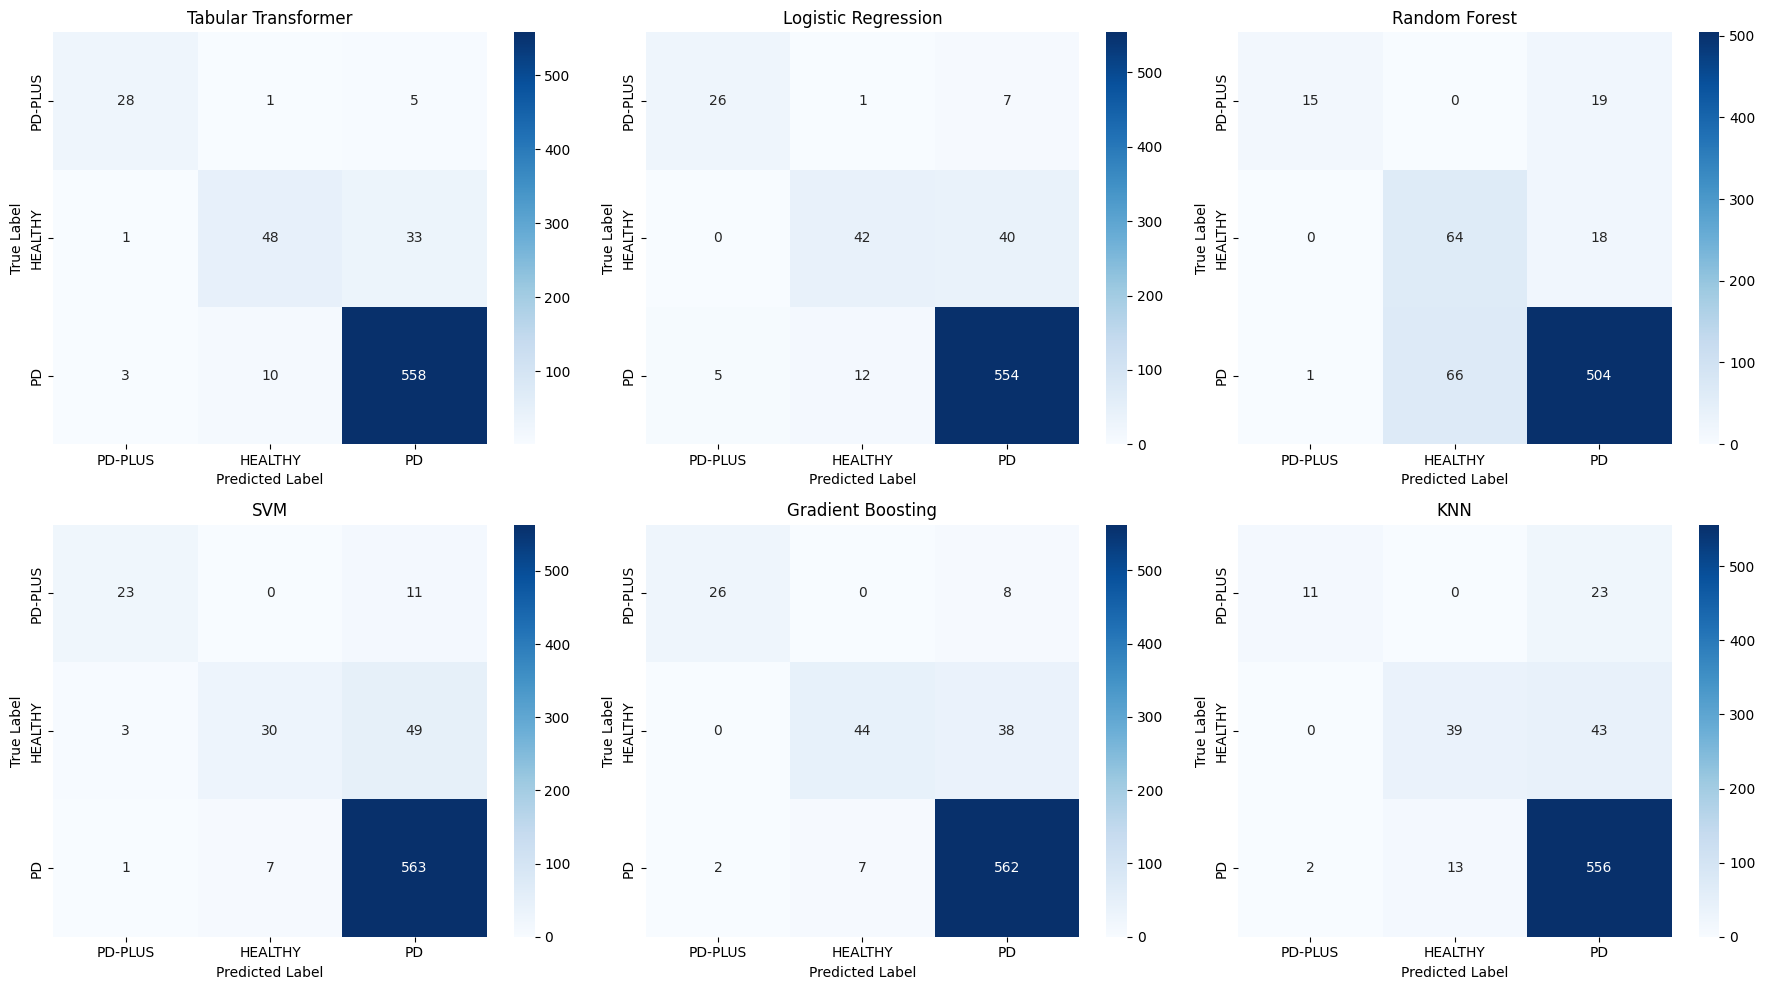

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, f1_score, 
    precision_score, recall_score, accuracy_score, cohen_kappa_score, 
    precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1. DEFINE RENAMED CLASSES
# Order matches: [Atypical (PD-PLUS), Healthy (HEALTHY), Parkinson's (PD)]
classes = ['PD-PLUS', 'HEALTHY', 'PD']

def calculate_overall_performance(y_true, y_pred, y_probs, model_name):
    """Calculates publication-ready aggregate metrics for the whole model."""
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC (Macro)": roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro'),
        "F1 (Macro)": f1_score(y_true, y_pred, average='macro'),
        "Precision (Macro)": precision_score(y_true, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_true, y_pred, average='macro'),
        "Kappa": cohen_kappa_score(y_true, y_pred)
    }
    return metrics

# Dictionary to store results for the final table and plots
all_model_performance = []
all_confusion_matrices = {}

# --- 1. TRANSFORMER RESULTS ---
# Assuming all_targets, final_preds, and all_probs are available
transformer_metrics = calculate_overall_performance(all_targets, final_preds, all_probs, "Tabular Transformer")
all_model_performance.append(transformer_metrics)
all_confusion_matrices["Tabular Transformer"] = confusion_matrix(all_targets, final_preds)

# --- 2. ML MODELS LOOP ---
for name, model in models.items():
    grid_search = GridSearchCV(Pipeline([('clf', model)]), param_grids[name], cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_clf = grid_search.best_estimator_
    
    probs = best_clf.predict_proba(X_test)
    
    # Threshold optimization (per class)
    best_thresholds_ml = []
    for i in range(len(classes)):
        p, r, t = precision_recall_curve((y_test == i).astype(int), probs[:, i])
        f1_sc = 2*(p*r)/(p+r+1e-10)
        best_thresholds_ml.append(t[np.argmax(f1_sc)] if np.argmax(f1_sc) < len(t) else 0.5)
    
    # Generate predictions using optimized thresholds
    ml_preds = [np.argmax(probs[j] - np.array(best_thresholds_ml)) for j in range(len(probs))]
    
    # Collect Metrics
    model_perf = calculate_overall_performance(y_test, ml_preds, probs, name)
    all_model_performance.append(model_perf)
    all_confusion_matrices[name] = confusion_matrix(y_test, ml_preds)

# --- REPORTING: PUBLICATION READY TABLE ---
results_df = pd.DataFrame(all_model_performance)

print("\n" + "="*30)
print("TABLE 1: OVERALL MODEL PERFORMANCE")
print("="*30)
# Format to 3 decimal places for publication
print(results_df.to_string(index=False, float_format=lambda x: "{:.3f}".format(x)))

# Optional: Export to CSV/LaTeX
# results_df.to_csv("model_performance.csv", index=False)

# --- GRID OF CONFUSION MATRICES ---
n_models = len(all_confusion_matrices)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, (name, cm) in enumerate(all_confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=classes, yticklabels=classes)
    axes[i].set_title(f"{name}")
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

# Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()